In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import confusion_matrix, classification_report, f1_score, accuracy_score, cohen_kappa_score, precision_score, recall_score
from sklearn.model_selection import KFold

In [2]:
LABEL_DICT = {
    "Sleep stage W": 0,
    "Sleep stage 1": 1,
    "Sleep stage 2": 2,
    "Sleep stage 3": 3,
    "Sleep stage 4": 3, # Usually N3 and N4 are merged
    "Sleep stage R": 4,
}
CLASS_LABELS = {
    "W": 0,
    "N1": 1,
    "N2": 2,
    "N3": 3,
    "R": 4
}

In [3]:
def plot_results(y_true, y_pred, histories):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    # 1. Plot Training/Validation Curves (Averaged over folds)
    plt.figure(figsize=(12, 5))
    
    # Average the losses across all folds for a cleaner plot
    avg_train_loss = np.mean([fh['train_loss'] for fh in histories], axis=0)
    avg_val_loss = np.mean([fh['val_loss'] for fh in histories], axis=0)
    
    score_reports = {
        "accuracy": [np.mean(fh['val_acc']) for fh in histories],
        "f1": [np.mean(fh['val_f1']) for fh in histories],
        "kappa": [np.mean(fh['val_kappa']) for fh in histories],
    }
    
    plt.subplot(1, 2, 1)
    plt.plot(avg_train_loss, label='Avg Train Loss')
    plt.plot(avg_val_loss, label='Avg Val Loss')
    plt.title('Cross-Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # 2. Confusion Matrix Plot
    plt.subplot(1, 2, 2)
    cm = confusion_matrix(y_true, y_pred)
    # Normalize CM to see percentages
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=CLASS_LABELS.keys(), 
                yticklabels=CLASS_LABELS.keys())
    plt.title('Aggregated Normalized Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    
    plt.tight_layout()
    plt.savefig('cv_performance_results.png')
    plt.show()

    # 3. Print Comprehensive Scores
    print("\n" + "="*30)
    print("FINAL 10-FOLD CV RESULTS")
    print("="*30)
    print(classification_report(y_true, y_pred, target_names=list(CLASS_LABELS.keys())))
    
    # 4. Report fold scores
    report_df = pd.DataFrame(score_reports, index=[f"fold {i + 1}" for i in range(len(histories))])
    print(f"\n\nFolds Score Report Summary")
    print(report_df)

In [4]:
class SleepNet(nn.Module):
    def __init__(self, num_classes=5, hidden_dim=128):
        super(SleepNet, self).__init__()
        # CNN to extract features from EACH 30s epoch
        self.feature_extractor = nn.Sequential(
            nn.Conv1d(1, 64, 50, stride=6, padding=25),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(8, 8),
            nn.Conv1d(64, 128, 8, padding=4),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.AdaptiveMaxPool1d(1) 
        )
        
        # Bi-LSTM to process the temporal context of the window
        self.lstm = nn.LSTM(input_size=128, 
                            hidden_size=hidden_dim, 
                            num_layers=2, 
                            batch_first=True, 
                            bidirectional=True,
                            dropout=0.5)
        
        # Classifier: input is hidden_dim * 2 because of Bidirectional
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        # x: (Batch, Window_Size, Channels, Time) -> (B, 5, 1, 3000)
        batch_size, win_size, C, T = x.shape
        
        # 1. Flatten for CNN
        x = x.view(batch_size * win_size, C, T)
        x = self.feature_extractor(x).squeeze(-1) # (B*5, 128)
        
        # 2. Reshape for LSTM
        x = x.view(batch_size, win_size, 128)
        
        # 3. Sequence Modeling
        lstm_out, _ = self.lstm(x) # (B, 5, 256)
        
        # 4. Attention / Centered Selection
        # Instead of taking the last step, we take the middle step
        # because the middle step has seen context from both sides.
        mid_idx = win_size // 2
        out = self.classifier(lstm_out[:, mid_idx, :])
        
        return out

In [ ]:
class SleepAttentionNet(nn.Module):
    def __init__(self, num_classes=5, embed_dim=128, num_heads=8, dropout=0.3):
        super(SleepAttentionNet, self).__init__()
        
        # 1. CNN Feature Extractor (Keeps spatial features)
        self.cnn = nn.Sequential(
            nn.Conv1d(1, 64, 50, stride=6, padding=25),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(8, 8),
            nn.Conv1d(64, 128, 8, padding=4),
            
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.AdaptiveMaxPool1d(1) 
        )
        
        # 2. Positional Encoding
        # Since Attention is permutation-invariant, we must tell it 
        # which epoch is "past" and which is "future".
        self.pos_embedding = nn.Parameter(torch.randn(1, 5, embed_dim))
        
        # 3. Multi-Head Attention Layer
        self.attention = nn.MultiheadAttention(embed_dim=embed_dim, 
                                               num_heads=num_heads, 
                                               dropout=dropout, 
                                               batch_first=True)
        
        self.layernorm = nn.LayerNorm(embed_dim)
        
        # 4. Final Classifier
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        # x shape: (Batch, Win_Size=5, Channels=1, Time=3000)
        B, W, C, T = x.shape
        
        # Extract features for each epoch
        x = x.view(B * W, C, T)
        x = self.cnn(x).squeeze(-1) # (B*W, 128)
        
        # Reshape to (Batch, Window, Embedding)
        x = x.view(B, W, 128)
        
        # Add Positional Information
        x = x + self.pos_embedding
        
        # Self-Attention
        # attn_output: (Batch, Window, Embedding)
        attn_output, _ = self.attention(x, x, x)
        x = self.layernorm(x + attn_output) # Residual connection
        
        # Focus on the middle epoch (index 2 for window size 5)
        mid_epoch_features = x[:, W // 2, :]
        
        return self.classifier(mid_epoch_features)

In [6]:
class SleepCenteredWindowDataset(Dataset):
    def __init__(self, file_paths, window_size=5, trim_margin_min=30):
        """
        window_size: must be odd (e.g., 5, 9, 21)
        """
        assert window_size % 2 != 0, "Window size must be an odd number."
        self.window_size = window_size
        self.half_win = window_size // 2
        self.features = []
        self.labels = []
        
        margin = (trim_margin_min * 60) // 30
        
        for path in file_paths:
            with np.load(path) as data:
                x, y = data['x'], data['y']
                
                # 1. Trimming based on sleep activity
                sleep_idx = np.where(y != 0)[0]
                if len(sleep_idx) == 0: continue
                start, end = max(0, sleep_idx[0]-margin), min(len(y), sleep_idx[-1]+margin+1)
                x, y = x[start:end], y[start:end]
                
                # 2. Subject-level Z-score Normalization
                x = (x - np.mean(x)) / (np.std(x) + 1e-8)
                
                # 3. Sliding Centered Window
                # We start from half_win and end at len - half_win
                for i in range(self.half_win, len(x) - self.half_win):
                    # Extract [i-2, i-1, i, i+1, i+2] if window_size is 5
                    window = x[i - self.half_win : i + self.half_win + 1]
                    self.features.append(window)
                    self.labels.append(y[i]) # Label of the middle epoch

        # Stack into tensors
        self.X = torch.from_numpy(np.array(self.features)).float()
        self.Y = torch.from_numpy(np.array(self.labels)).long()

    def __len__(self):
        return len(self.Y)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

In [7]:
class SleepSubjectDataset(Dataset):
    def __init__(self, file_paths, trim_margin_min=30):
        self.samples = []
        self.labels = []
        margin = (trim_margin_min * 60) // 30
        
        for path in file_paths:
            with np.load(path) as data:
                x, y = data['x'], data['y']
                # Trimming logic
                sleep_idx = np.where(y != 0)[0]
                if len(sleep_idx) > 0:
                    start, end = max(0, sleep_idx[0]-margin), min(len(y), sleep_idx[-1]+margin+1)
                    x, y = x[start:end], y[start:end]
                    
                    # Normalize per subject (Z-score)
                    x = (x - np.mean(x)) / (np.std(x) + 1e-8)
                    
                    self.samples.append(torch.from_numpy(x).float())
                    self.labels.append(torch.from_numpy(y).long())

        # Flatten for the DataLoader, but we kept them separate during loading
        self.X = torch.cat(self.samples, dim=0)
        self.Y = torch.cat(self.labels, dim=0)

    def __len__(self): return len(self.Y)
    def __getitem__(self, idx): return self.X[idx], self.Y[idx]

In [11]:
class Trainer:
    def __init__(self, model, device, fold_idx):
        self.model = model.to(device)
        self.device = device
        self.fold_idx = fold_idx
        self.best_val_loss = float('inf')
        self.history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

    def train_epoch(self, loader, optimizer, criterion):
        self.model.train()
        total_loss = 0
        for x, y in loader:
            x, y = x.to(self.device), y.to(self.device)
            optimizer.zero_grad()
            out = self.model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        return total_loss / len(loader)

    def validate(self, loader, criterion):
        self.model.eval()
        total_loss = 0
        all_preds, all_labels = [], []
        
        with torch.no_grad():
            for x, y in loader:
                x, y = x.to(self.device), y.to(self.device)
                out = self.model(x)
                loss = criterion(out, y)
                total_loss += loss.item()
                preds = out.argmax(dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(y.cpu().numpy())
                
        avg_loss = total_loss / len(loader)
        scores = {
            "accuracy": accuracy_score(all_labels, all_preds),
            "f1": f1_score(all_labels, all_preds, average='macro'),
            "precision": precision_score(all_labels, all_preds, average='macro'),
            "recall": recall_score(all_labels, all_preds, average='macro'),
            "kappa": cohen_kappa_score(all_labels, all_preds)
        }
        return avg_loss, scores, all_preds, all_labels

    def save_checkpoint(self, val_loss):
        if val_loss < self.best_val_loss:
            self.best_val_loss = val_loss
            torch.save(self.model.state_dict(), f"checkpoints/best_model_fold_{self.fold_idx}.pt")

In [12]:
def run_kfold(window_size=5):
    data_path = "/home/kasra/courses/2026-edge-computing/project/dataset/sleepEDF/processed/SC"
    all_files = np.array(sorted(glob.glob(os.path.join(data_path, "*.npz"))))
    
    # Define 10-fold cross-validation on files (subjects)
    n_folds = 10
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    print("Device: ", device)
    
    # Storage for overall metrics
    all_fold_preds = []
    all_fold_labels = []
    fold_histories = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(all_files)):
        print(f"\n{'='*20} Fold {fold+1}/{n_folds} {'='*20}")
        
        # 1. Initialize Datasets (Subject-wise split)
        train_ds = SleepCenteredWindowDataset(all_files[train_idx], window_size=window_size)
        val_ds = SleepCenteredWindowDataset(all_files[val_idx], window_size=window_size)
        
        train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=0)
        val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)

        # 2. Setup Model, Loss (Weighted), and Optimizer
        model = SleepAttentionNet(num_classes=5).to(device)
        
        # Compute class weights for this fold to handle imbalance
        counts = np.bincount(train_ds.Y.numpy())
        weights = 1.0 / torch.tensor(counts, dtype=torch.float32).to(device)
        criterion = torch.nn.CrossEntropyLoss(weight=weights)
        
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
        
        # 3. Training/Validation Loop
        trainer = Trainer(model, device, fold) # Uses the Trainer class from previous step
        fold_history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_f1': [], 'val_kappa': []}
        best_fold_preds = None
        best_fold_labels = None

        for epoch in range(30):  # Adjust epochs as needed
            t_loss = trainer.train_epoch(train_loader, optimizer, criterion)
            v_loss, v_scores, preds, labels = trainer.validate(val_loader, criterion)
            scheduler.step(v_loss)
            
            fold_history['train_loss'].append(t_loss)
            fold_history['val_loss'].append(v_loss)
            fold_history['val_acc'].append(v_scores["accuracy"])
            fold_history['val_f1'].append(v_scores["f1"])
            fold_history['val_kappa'].append(v_scores["kappa"])
            
            # Checkpoint: Save if best val_loss
            if v_loss < trainer.best_val_loss:
                trainer.best_val_loss = v_loss
                torch.save(model.state_dict(), f"checkpoints/best_model_fold_{fold}.pt")
                best_fold_preds = preds
                best_fold_labels = labels
            
            if epoch % 5 == 0:
                print(f"Epoch {epoch:02d} | T-Loss: {t_loss:.4f} | V-Loss: {v_loss:.4f} | V-Acc: {v_scores["accuracy"]:.2f} | V-kappa: {v_scores["kappa"]:.2f}")

        # Store results for this fold
        all_fold_preds.extend(best_fold_preds)
        all_fold_labels.extend(best_fold_labels)
        fold_histories.append(fold_history)

    # 4. Final Analysis and Plotting
    plot_results(all_fold_labels, all_fold_preds, fold_histories)

Device:  cuda

==================== Fold 1/10 ====================
Epoch 00 | T-Loss: 0.6861 | V-Loss: 0.5653 | V-Acc: 0.79 | V-kappa: 0.73
Epoch 05 | T-Loss: 0.4987 | V-Loss: 0.4778 | V-Acc: 0.78 | V-kappa: 0.72
Epoch 10 | T-Loss: 0.4109 | V-Loss: 0.5169 | V-Acc: 0.79 | V-kappa: 0.72
Epoch 15 | T-Loss: 0.3260 | V-Loss: 0.6422 | V-Acc: 0.81 | V-kappa: 0.75
Epoch 20 | T-Loss: 0.2762 | V-Loss: 0.7009 | V-Acc: 0.80 | V-kappa: 0.74
Epoch 25 | T-Loss: 0.2482 | V-Loss: 0.7786 | V-Acc: 0.80 | V-kappa: 0.74

==================== Fold 2/10 ====================
Epoch 00 | T-Loss: 0.6801 | V-Loss: 0.5808 | V-Acc: 0.76 | V-kappa: 0.67
Epoch 05 | T-Loss: 0.4960 | V-Loss: 0.5478 | V-Acc: 0.78 | V-kappa: 0.71
Epoch 10 | T-Loss: 0.3988 | V-Loss: 0.5546 | V-Acc: 0.79 | V-kappa: 0.71
Epoch 15 | T-Loss: 0.3536 | V-Loss: 0.6125 | V-Acc: 0.74 | V-kappa: 0.66
Epoch 20 | T-Loss: 0.2636 | V-Loss: 0.6258 | V-Acc: 0.79 | V-kappa: 0.72
Epoch 25 | T-Loss: 0.2292 | V-Loss: 0.7398 | V-Acc: 0.80 | V-kappa: 0.73

===

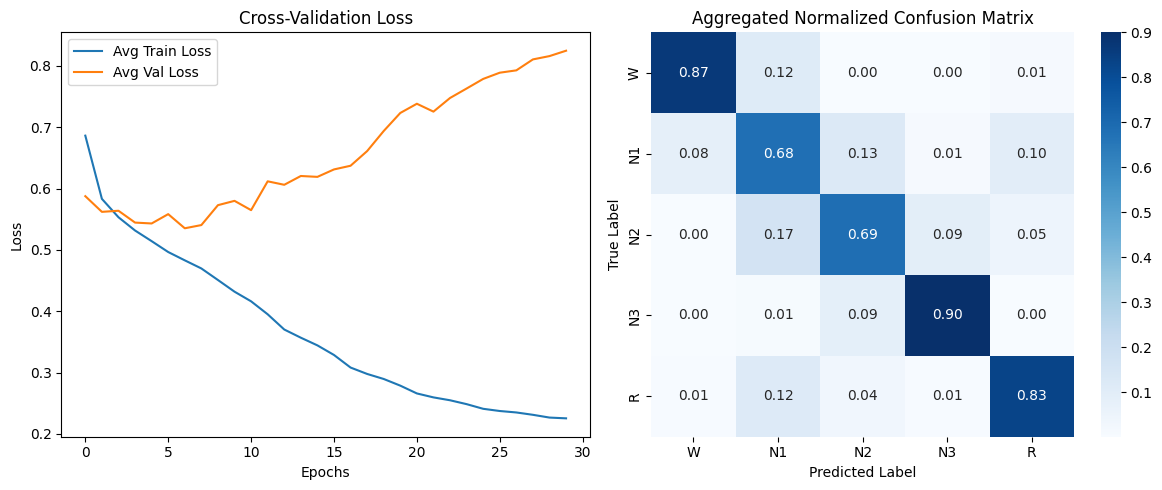


FINAL 10-FOLD CV RESULTS
              precision    recall  f1-score   support

           W       0.96      0.87      0.91     65341
          N1       0.39      0.68      0.50     21520
          N2       0.91      0.69      0.78     69132
          N3       0.63      0.90      0.74     13039
           R       0.77      0.83      0.80     25835

    accuracy                           0.78    194867
   macro avg       0.73      0.79      0.75    194867
weighted avg       0.83      0.78      0.79    194867



Folds Score Report Summary
         accuracy        f1     kappa
fold 1   0.791727  0.764950  0.728701
fold 2   0.785750  0.741758  0.712434
fold 3   0.773619  0.734749  0.698379
fold 4   0.766164  0.739353  0.692082
fold 5   0.787927  0.713978  0.707561
fold 6   0.759072  0.732547  0.680337
fold 7   0.793056  0.729437  0.717186
fold 8   0.742788  0.706012  0.658059
fold 9   0.799429  0.744363  0.726861
fold 10  0.793624  0.748236  0.724957


In [13]:
if __name__ == "__main__":
    # This ensures that child workers don't execute run_kfold() again
    run_kfold(window_size=5)

## DEBUG

In [ ]:
margin = (30 * 60) // 30
samples = []
labels = []
data_path = "/home/kasra/courses/2026-edge-computing/project/dataset/sleepEDF/processed/SC"
file_paths = np.array(glob.glob(os.path.join(data_path, "*.npz")))

for path in file_paths:
    with np.load(path) as data:
        x, y = data['x'], data['y']
        # Trimming logic
        sleep_idx = np.where(y != 0)[0]
        if len(sleep_idx) > 0:
            start, end = max(0, sleep_idx[0]-margin), min(len(y), sleep_idx[-1]+margin+1)
            x, y = x[start:end], y[start:end]
            
            # Normalize per subject (Z-score)
            x = (x - np.mean(x)) / (np.std(x) + 1e-8)
            
            samples.append(torch.from_numpy(x).float())
            labels.append(torch.from_numpy(y).long())

# Flatten for the DataLoader, but we kept them separate during loading
X = torch.cat(samples, dim=0)
Y = torch.cat(labels, dim=0)

In [ ]:
X.shape

torch.Size([195479, 1, 3000])